In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
df = pd.read_csv("../nyc311.csv")
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 23:59,1/1/2016 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 23:59,1/1/2016 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 23:59,1/1/2016 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 23:57,1/1/2016 7:43,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 23:56,1/1/2016 3:24,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      35000 non-null  int64  
 1   Created Date                    35000 non-null  str    
 2   Closed Date                     34793 non-null  str    
 3   Agency                          35000 non-null  str    
 4   Agency Name                     35000 non-null  str    
 5   Complaint Type                  35000 non-null  str    
 6   Descriptor                      34510 non-null  str    
 7   Location Type                   35000 non-null  str    
 8   Incident Zip                    34767 non-null  float64
 9   Incident Address                30933 non-null  str    
 10  Street Name                     30933 non-null  str    
 11  Cross Street 1                  30396 non-null  str    
 12  Cross Street 2                  30351 non-n

Unique Key                            0
Created Date                          0
Closed Date                         207
Agency                                0
Agency Name                           0
Complaint Type                        0
Descriptor                          490
Location Type                         0
Incident Zip                        233
Incident Address                   4067
Street Name                        4067
Cross Street 1                     4604
Cross Street 2                     4649
Intersection Street 1             30966
Intersection Street 2             31011
Address Type                        260
City                                233
Landmark                          34979
Facility Type                       203
Status                                0
Due Date                              0
Resolution Description                0
Resolution Action Updated Date      203
Community Board                       0
Borough                               0


In [4]:
df = df.drop_duplicates()
df = df.dropna(subset=["Complaint Type"])

In [5]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [6]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'location_type', 'incident_zip',
       'incident_address', 'street_name', 'cross_street_1', 'cross_street_2',
       'intersection_street_1', 'intersection_street_2', 'address_type',
       'city', 'landmark', 'facility_type', 'status', 'due_date',
       'resolution_description', 'resolution_action_updated_date',
       'community_board', 'borough', 'x_coordinate_(state_plane)',
       'y_coordinate_(state_plane)', 'park_facility_name', 'park_borough',
       'school_name', 'school_number', 'school_region', 'school_code',
       'school_phone_number', 'school_address', 'school_city', 'school_state',
       'school_zip', 'school_not_found', 'school_or_citywide_complaint',
       'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location',
       'bridge_highway_name', 'bridge_highway_direction', 'road_ramp',
       'bridge_highway_segment', 'garage_lot_name', 'ferry_

In [7]:
department_mapping = {
    "noise street/sidewalk": "Police",
    "blocked driveway": "Transport",
    "water leak": "Water Department",
    "street condition": "Road Maintenance",
    "illegal parking": "Traffic",
    "garbage": "Sanitation"
}

In [8]:
df["department"] = df["complaint_type"].str.lower().map(department_mapping)

In [9]:
df["complaint_type"].value_counts().head(10)

complaint_type
Blocked Driveway           11170
Illegal Parking             9960
Noise - Commercial          4515
Noise - Street/Sidewalk     3086
Derelict Vehicle            2097
Noise - Vehicle             1453
Animal Abuse                 885
Traffic                      472
Homeless Encampment          388
Vending                      372
Name: count, dtype: int64

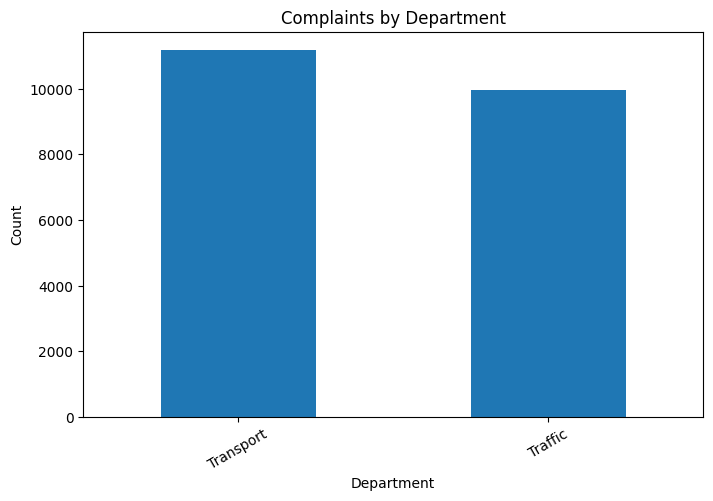

In [10]:
plt.figure(figsize=(8,5))

df["department"].value_counts().plot(kind="bar")

plt.title("Complaints by Department")
plt.xlabel("Department")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

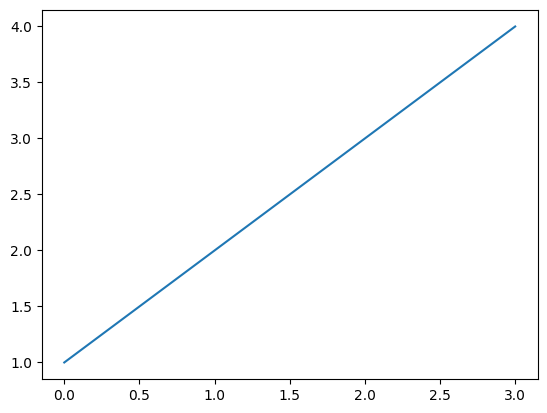

In [11]:
import matplotlib.pyplot as plt
plt.plot([1,2,3,4])
plt.show

In [12]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub("[^a-zA-Z\\s]", "", text)
    return text

df["clean_text"] = df["complaint_type"].apply(clean_text)
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,...,road_ramp,bridge_highway_segment,garage_lot_name,ferry_direction,ferry_terminal_name,latitude,longitude,location,department,clean_text
0,32310363,12/31/2015 23:59,1/1/2016 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)",NaN,noise streetsidewalk
1,32309934,12/31/2015 23:59,1/1/2016 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)",Transport,blocked driveway
2,32309159,12/31/2015 23:59,1/1/2016 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)",Transport,blocked driveway
3,32305098,12/31/2015 23:57,1/1/2016 7:43,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)",Traffic,illegal parking
4,32306529,12/31/2015 23:56,1/1/2016 3:24,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)",Traffic,illegal parking


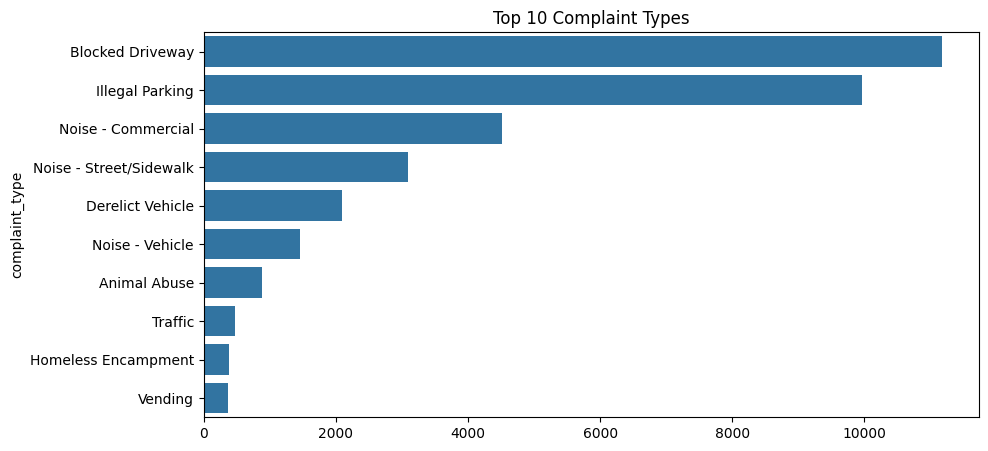

In [13]:
top = df["complaint_type"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top.values, y=top.index)
plt.title("Top 10 Complaint Types")
plt.show()

In [14]:
if "city" in df.columns:
    df["city"].value_counts().head(10)

In [15]:
import pandas as pd

df = pd.read_csv("../nyc311.csv")

df.head(35000).to_csv(
    "../nyc311.csv",
    index=False
)

print("Small dataset created successfully!")

Small dataset created successfully!


# Week 1 Insights

- Dataset loaded successfully
- Missing values handled
- Duplicate records removed
- Complaint Type is the most important field
- Top complaints identified using visualization